In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [62]:
X, y = make_classification(
    n_features= 2, n_redundant= 0, n_informative= 2, n_clusters_per_class= 1, n_samples= 100,flip_y= 0.1, random_state= 42)
kernels = ['linear', 'rbf', 'poly']
plt.figure(figsize= (15, 5))

<Figure size 1500x500 with 0 Axes>

<Figure size 1500x500 with 0 Axes>

In [63]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

accuracy with linear kernel: 0.80
accuracy with rbf kernel: 0.80
accuracy with poly kernel: 0.80


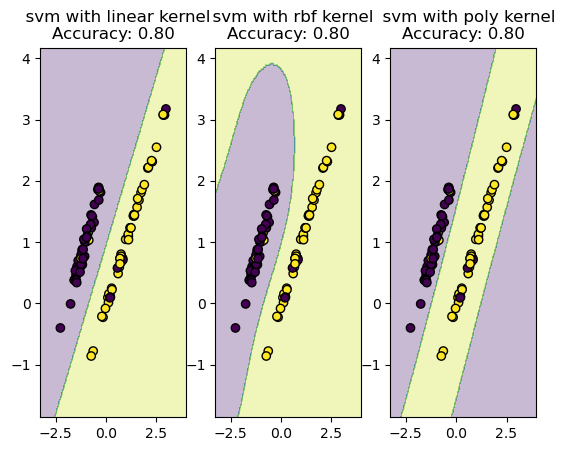

In [64]:
for i, kernel in enumerate(kernels, 1):
    clf = svm.SVC(kernel= kernel, degree= 2, gamma= 'auto')
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"accuracy with {kernel} kernel: {acc:.2f}")
    xx, yy = np.meshgrid(
        np.linspace(X[:,0].min()-1, X[:,0].max()+1, 200),
        np.linspace(X[:,1].min()-1, X[:,1].max()+1, 200)
    )
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.subplot(1,3, i)
    plt.contourf(xx, yy, Z, alpha = 0.3)
    plt.scatter(X[:,0],X[:,1], c = y, edgecolors='k')
    plt.title(f"  svm with {kernel} kernel\nAccuracy: {acc:.2f}")
plt.show()